In [ ]:
import numpy as np

GM = 3.986e14
R = 6371000

def orbital_velocity(altitude_m):
    return np.sqrt(GM / (R + altitude_m))

def atmospheric_density_v2(altitude_m):
    h = altitude_m / 1000
    if h < 150:
        return 1.225 * np.exp(-h / 8.5)
    elif h < 300:
        return 1.225 * np.exp(-150/8.5) * np.exp(-(h-150) / 40)
    elif h < 500:
        return 2.08e-9 * np.exp(-(h-300) / 60)
    else:
        return 5.3e-11 * np.exp(-(h-500) / 80)

def altitude_loss(altitude_m, dt):
    rho = atmospheric_density_v2(altitude_m)
    v = orbital_velocity(altitude_m)
    drag = 0.5 * rho * v**2 * 2.2 * 0.03
    deceleration = drag / 4.0
    delta_v = deceleration * dt
    delta_h = (2 * (R + altitude_m) * delta_v) / v
    return delta_h * 0.001

loss = altitude_loss(400000, 3600)
print(f"Loss per hour: {loss:.6f} meters")
print(f"Loss per day: {loss*24:.4f} meters")
print(f"Loss per year: {loss*24*365:.2f} meters")



Loss per hour: 1.212330 meters
Loss per day: 29.0959 meters
Loss per year: 10620.01 meters


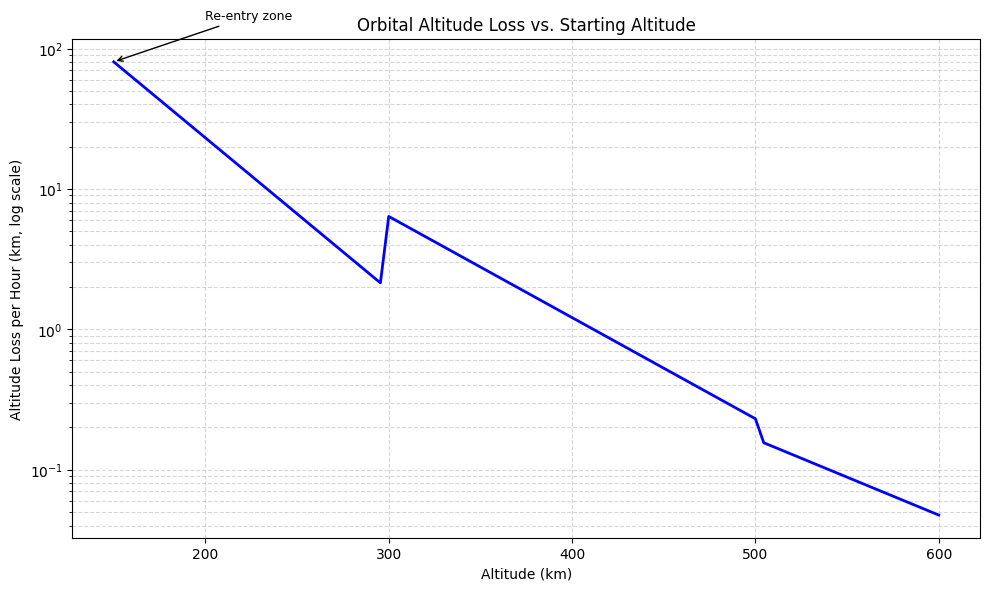

In [ ]:
import matplotlib.pyplot as plt

# Define the range of altitudes (150km to 600km)
altitudes = np.linspace(150000, 600000, 100)
losses = [altitude_loss(h, 3600) for h in altitudes]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(altitudes / 1000, losses, color='blue', linewidth=2)
plt.yscale('log') # Log scale since density drops exponentially

plt.title('Orbital Altitude Loss vs. Starting Altitude')
plt.xlabel('Altitude (km)')
plt.ylabel('Altitude Loss per Hour (km, log scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Pointing to the 150km mark (start of the array) as the re-entry zone
plt.annotate('Re-entry zone', xy=(altitudes[0] / 1000, losses[0]),
             xytext=((altitudes[0] / 1000) + 50, losses[0] * 2),
             arrowprops=dict(arrowstyle='->'),
             fontsize=9)
plt.tight_layout()

plt.show()

### Calculating RMSE
To calculate RMSE, we need 'Observed' data to compare against our 'Predicted' values. Below we define some hypothetical observed values for altitude loss at specific heights to demonstrate the error calculation.

In [ ]:
import numpy as np
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [1]:
import numpy as np

idx = np.arange(len(df))
np.random.shuffle(idx)

n = len(df)
n_val = round(0.2 * n)
n_test = round(0.2 * n)
n_train = n - n_val - n_test

idx_train = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_test = idx[n_train + n_val:]

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val = df.iloc[idx_val].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

y_train = np.log1p(df_train["MSRP"]).values
X_train = df_train.drop(columns=["MSRP"])

NameError: name 'df' is not defined